# BESS Trajectory Analysis: Senegal 2030-2050

Compares solved PyPSA-Earth networks across five planning horizons (2030, 2035, 2040, 2045,
2050), each in a "No BESS" and a "BESS" variant, extending the pairwise Run A/B comparison in
`BESS_Cost_Structure_Analysis.ipynb` into a full trajectory.

**Not all 10 runs exist yet.** This notebook loads whatever is available under
`results/baseline_{no_bess,bess}_{year}_overnight/` and shows gaps explicitly (missing points
on trajectory lines, missing panels) rather than failing -- rerun cells as more scenarios finish
solving. Section 1 prints the current availability matrix.

2030, 2040, 2050 use published GEGIS/SSP2-2.6 demand data; 2035 and 2045 use the linearly
interpolated demand datasets built earlier (`data/ssp2-2.6/{2035,2045}/era5_2013/Africa.nc`),
since those years aren't natively published. See the config's `load_options.prediction_year`
and `costs.year` for how each `{year}` run was parameterised.

## 0. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

PALETTE = {
    "blue_teal": "#0B4F6C", "amber": "#E8A33D", "slate": "#4A6572",
    "burgundy": "#7A3B46", "green": "#4B7A63", "teal_light": "#7FB3B3",
}
# Carrier colors, matching BESS_Cost_Structure_Analysis.ipynb for visual consistency across notebooks
CARRIER_COLORS = {
    "solar": PALETTE["amber"], "onwind": PALETTE["green"], "CCGT": PALETTE["slate"],
    "coal": PALETTE["burgundy"], "oil": PALETTE["burgundy"], "battery": PALETTE["blue_teal"],
    "hydro": PALETTE["teal_light"],
}
def color_for(carrier):
    return CARRIER_COLORS.get(carrier, "#999999")

BESS_COLORS = {"no_bess": PALETTE["slate"], "bess": PALETTE["blue_teal"]}
BESS_LABELS = {"no_bess": "No BESS", "bess": "BESS"}

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "font.size": 12, "axes.titlesize": 14,
    "axes.labelsize": 12, "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "axes.spines.top": False, "axes.spines.right": False, "figure.autolayout": True,
})

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def savefig(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"saved {path}")

def stat_total(stats_result):
    if isinstance(stats_result, pd.DataFrame):
        return stats_result.sum(axis=1)
    return stats_result

YEARS = [2030, 2035, 2040, 2045, 2050]
BESS_STATES = ["no_bess", "bess"]

def run_path(year, bess):
    return Path(f"results/baseline_{bess}_{year}_overnight/networks/elec_s_24_ec_lv1.0_1h.nc")


## 1. Load Available Networks

In [2]:
networks = {}
for year in YEARS:
    for bess in BESS_STATES:
        p = run_path(year, bess)
        networks[(year, bess)] = pypsa.Network(str(p)) if p.exists() else None

avail = pd.DataFrame(
    {BESS_LABELS[b]: ["done" if networks[(y, b)] is not None else "-- pending --" for y in YEARS] for b in BESS_STATES},
    index=YEARS,
)
avail.index.name = "year"
n_done = sum(1 for v in networks.values() if v is not None)
print(f"{n_done} of {len(YEARS) * len(BESS_STATES)} runs available:")
avail


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


...

INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


INFO:pypsa.io:Imported network elec_s_24_ec_lv1.0_1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


10 of 10 runs available:


,No BESS,BESS
year,,
2030,done,done
2035,done,done
2040,done,done
2045,done,done
2050,done,done


## 2. System-Average Cost per MWh Served, 2030-2050

Same metric as Section 10 of `BESS_Cost_Structure_Analysis.ipynb` (full annualised system cost
/ annual demand), computed for every available run and plotted as a trajectory. Each point is
its own annualised, steady-state "if this system were fully built and run for one year" figure
-- not a continuous investment path across years (this model uses `foresight: overnight`, not
`myopic`/`perfect`, so there's no shared capacity carried between horizon years).

saved figures/trajectory_cost_per_mwh.png


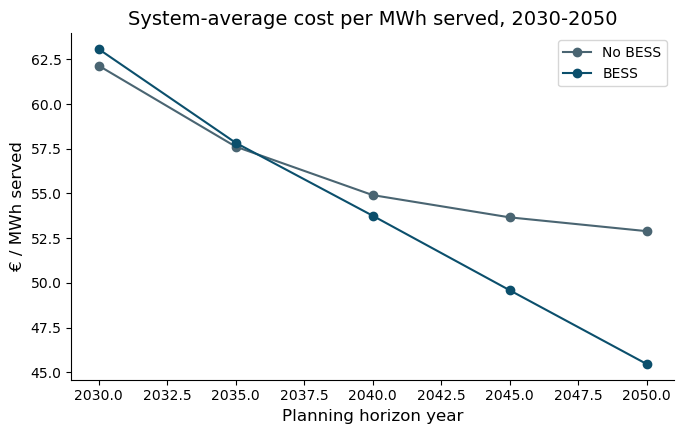

bess,bess,no_bess
year,,
2030,63.074002,62.146445
2035,57.834911,57.620112
2040,53.757231,54.909902
2045,49.591186,53.664839
2050,45.466522,52.893545


In [3]:
def system_cost_per_mwh(n):
    capex = stat_total(n.statistics.capex()).sum()
    opex = stat_total(n.statistics.opex()).sum()
    w = n.snapshot_weightings.generators
    demand = (n.loads_t.p_set.sum(axis=1) * w).sum()
    return (capex + opex) / demand

cost_rows = []
for year in YEARS:
    for bess in BESS_STATES:
        n = networks[(year, bess)]
        if n is None:
            continue
        cost_rows.append({"year": year, "bess": bess, "eur_per_mwh": system_cost_per_mwh(n)})
cost_df = pd.DataFrame(cost_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
for bess in BESS_STATES:
    d = cost_df[cost_df.bess == bess].sort_values("year")
    if len(d) == 0:
        continue
    ax.plot(d.year, d.eur_per_mwh, marker="o", color=BESS_COLORS[bess], label=BESS_LABELS[bess])
ax.set_xlabel("Planning horizon year")
ax.set_ylabel("€ / MWh served")
ax.set_title("System-average cost per MWh served, 2030-2050")
ax.legend()
savefig(fig, "trajectory_cost_per_mwh")
plt.show()

cost_df.pivot(index="year", columns="bess", values="eur_per_mwh")


## 3. BESS Value Over Time

The actual thesis question: does BESS's cost advantage grow or shrink as the system scales
toward 2050? Only plottable for years where *both* variants exist.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


saved figures/trajectory_bess_value.png


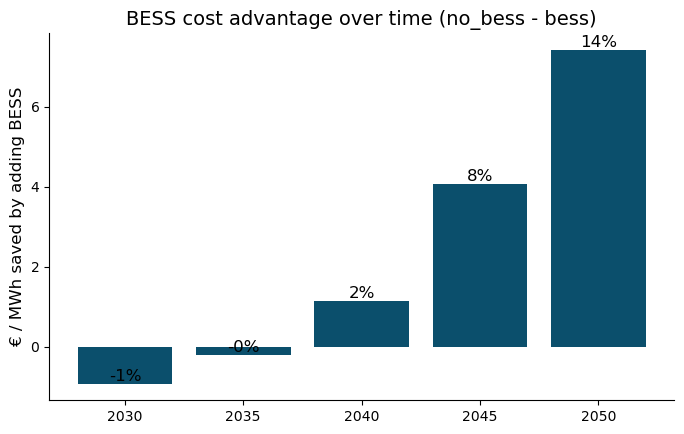

In [4]:
pivot = cost_df.pivot(index="year", columns="bess", values="eur_per_mwh")
both_years = [y for y in YEARS if y in pivot.index and pivot.loc[y].notna().all()]

if both_years:
    delta = pd.DataFrame({
        "no_bess_eur_per_mwh": pivot.loc[both_years, "no_bess"],
        "bess_eur_per_mwh": pivot.loc[both_years, "bess"],
    })
    delta["saving_eur_per_mwh"] = delta["no_bess_eur_per_mwh"] - delta["bess_eur_per_mwh"]
    delta["saving_pct"] = 100 * delta["saving_eur_per_mwh"] / delta["no_bess_eur_per_mwh"]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(delta.index.astype(str), delta["saving_eur_per_mwh"], color=PALETTE["blue_teal"])
    ax.set_ylabel("€ / MWh saved by adding BESS")
    ax.set_title("BESS cost advantage over time (no_bess - bess)")
    for i, (y, row) in enumerate(delta.iterrows()):
        ax.annotate(f"{row.saving_pct:.0f}%", (i, row.saving_eur_per_mwh), ha="center", va="bottom")
    savefig(fig, "trajectory_bess_value")
    plt.show()
    delta
else:
    print("No year has both No BESS and BESS solved yet -- nothing to compare. "
          "Currently only 2050 has both variants; run the BESS variant for at least one more "
          "year (2035/2040/2045) to populate this chart.")


## 4. Capacity Mix Trajectory

Installed capacity by carrier, faceted by BESS state, across all available years.

saved figures/trajectory_capacity_mix.png


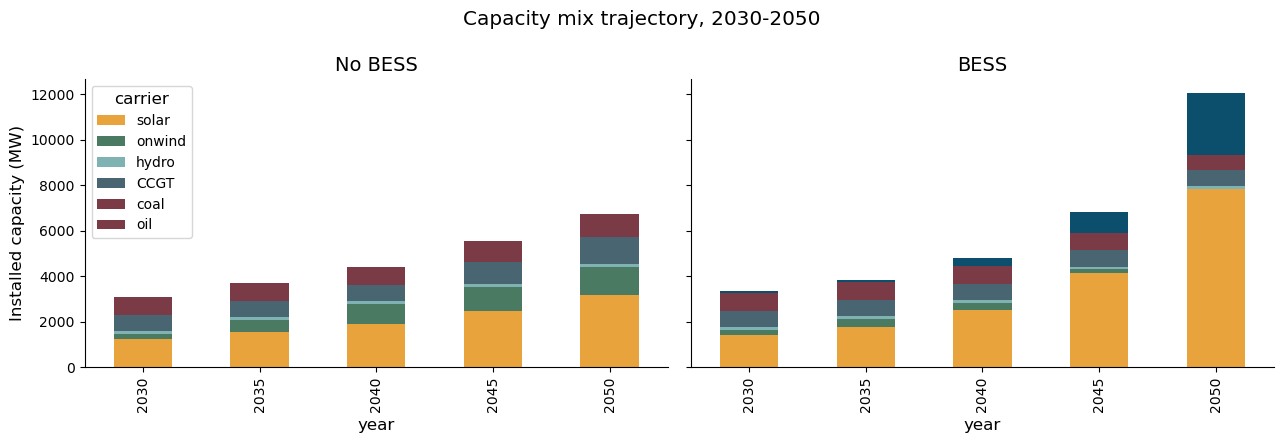

In [5]:
def capacity_by_carrier(n):
    '''Capacity by carrier, combining all three PyPSA component types that carry it in this
    model: Generator (solar/onwind/CCGT/coal/oil), StorageUnit (hydro -- always; battery -- the
    4 named custom BESS projects, non-extendable), and the extendable battery fleet's power
    rating via its Link "battery charger" (only the charger carries a nonzero capital_cost in
    this model -- the discharger's is 0, so charger p_nom_opt is the economically meaningful
    battery MW figure, matching the CAPEX chart in BESS_Cost_Structure_Analysis.ipynb).'''
    capacity = n.generators.p_nom_opt.where(n.generators.p_nom_extendable, n.generators.p_nom)
    cap = capacity.groupby(n.generators.carrier).sum().drop("load shedding", errors="ignore")

    if len(n.storage_units):
        su_cap = n.storage_units.p_nom_opt.where(n.storage_units.p_nom_extendable, n.storage_units.p_nom)
        su_cap = su_cap.groupby(n.storage_units.carrier).sum()
        cap = cap.add(su_cap, fill_value=0)

    charger = [c for c in n.links.index if "battery charger" in c]
    if charger:
        sub = n.links.loc[charger]
        charger_mw = sub["p_nom_opt"].where(sub["p_nom_extendable"], sub["p_nom"]).sum()
        cap["battery"] = cap.get("battery", 0) + charger_mw
    return cap

cap_rows = []
for year in YEARS:
    for bess in BESS_STATES:
        n = networks[(year, bess)]
        if n is None:
            continue
        for carrier, val in capacity_by_carrier(n).items():
            cap_rows.append({"year": year, "bess": bess, "carrier": carrier, "MW": val})
cap_df = pd.DataFrame(cap_rows)

carrier_order = ["solar", "onwind", "hydro", "CCGT", "coal", "oil", "battery"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, bess in zip(axes, BESS_STATES):
    d = cap_df[cap_df.bess == bess]
    if len(d) == 0:
        ax.set_title(f"{BESS_LABELS[bess]} (no runs yet)")
        ax.set_xlabel("year")
        continue
    piv = d.pivot(index="year", columns="carrier", values="MW").fillna(0)
    present = [c for c in carrier_order if c in piv.columns]
    piv[present].plot(kind="bar", stacked=True, ax=ax, color=[color_for(c) for c in present], legend=(bess == "no_bess"))
    ax.set_title(BESS_LABELS[bess])
    ax.set_xlabel("year")
axes[0].set_ylabel("Installed capacity (MW)")
fig.suptitle("Capacity mix trajectory, 2030-2050")
savefig(fig, "trajectory_capacity_mix")
plt.show()


## 5. Generation Mix Trajectory (TWh)

saved figures/trajectory_generation_mix.png


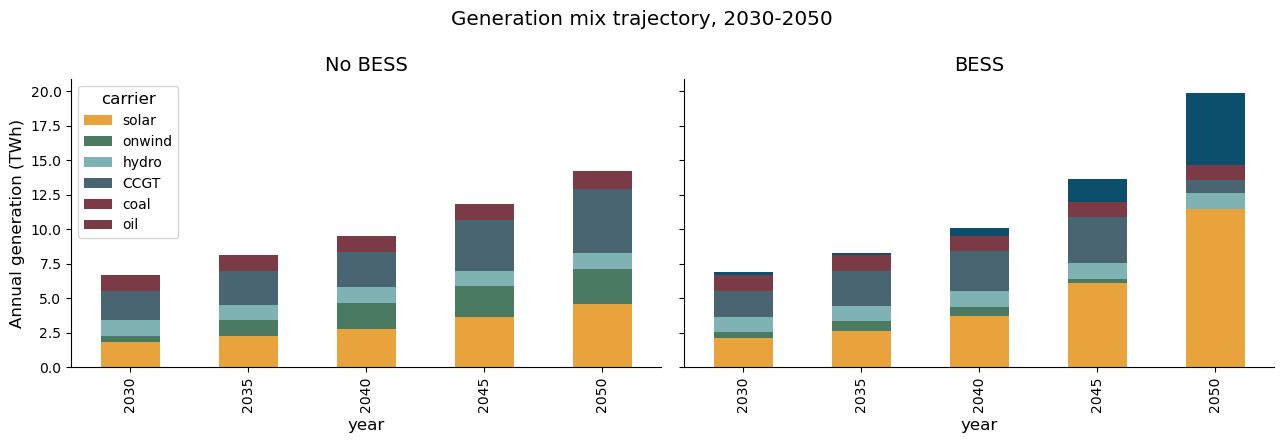

In [6]:
def generation_twh_by_carrier(n):
    '''Generation by carrier, TWh/year. Same three-component-type combination as
    capacity_by_carrier: Generator dispatch, StorageUnit discharge (hydro, custom BESS --
    clipped to >=0, matching a "generation stack" convention), and the extendable battery
    fleet's discharge via its Link "battery discharger" (p1, clipped to >=0).'''
    w = n.snapshot_weightings.generators
    by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    gen = (by_carrier.mul(w, axis=0).sum() / 1e6).drop("load shedding", errors="ignore")

    if len(n.storage_units):
        su_p = n.storage_units_t.p.clip(lower=0)
        su_twh = su_p.T.groupby(n.storage_units.carrier).sum().T.mul(w, axis=0).sum() / 1e6
        gen = gen.add(su_twh, fill_value=0)

    discharger = [c for c in n.links.index if "battery discharger" in c]
    if discharger:
        discharge_mw = (-n.links_t.p1[discharger]).clip(lower=0)
        discharge_twh = discharge_mw.mul(w, axis=0).sum().sum() / 1e6
        gen["battery"] = gen.get("battery", 0) + discharge_twh
    return gen

gen_rows = []
for year in YEARS:
    for bess in BESS_STATES:
        n = networks[(year, bess)]
        if n is None:
            continue
        for carrier, val in generation_twh_by_carrier(n).items():
            gen_rows.append({"year": year, "bess": bess, "carrier": carrier, "TWh": val})
gen_df = pd.DataFrame(gen_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, bess in zip(axes, BESS_STATES):
    d = gen_df[gen_df.bess == bess]
    if len(d) == 0:
        ax.set_title(f"{BESS_LABELS[bess]} (no runs yet)")
        ax.set_xlabel("year")
        continue
    piv = d.pivot(index="year", columns="carrier", values="TWh").fillna(0)
    present = [c for c in carrier_order if c in piv.columns]
    piv[present].plot(kind="bar", stacked=True, ax=ax, color=[color_for(c) for c in present], legend=(bess == "no_bess"))
    ax.set_title(BESS_LABELS[bess])
    ax.set_xlabel("year")
axes[0].set_ylabel("Annual generation (TWh)")
fig.suptitle("Generation mix trajectory, 2030-2050")
savefig(fig, "trajectory_generation_mix")
plt.show()


## 6. Curtailment Rate Trajectory

Combined solar+onwind curtailment rate (curtailed / potential), same definition as Section 11
of `BESS_Cost_Structure_Analysis.ipynb`.

saved figures/trajectory_curtailment.png


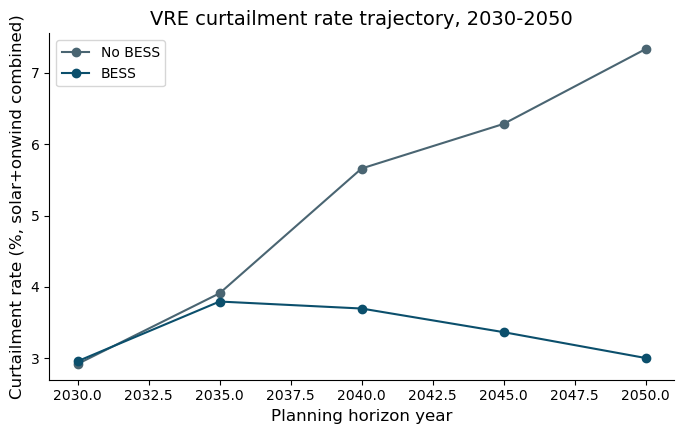

bess,bess,no_bess
year,,
2030,2.958037,2.919840
2035,3.795438,3.910930
2040,3.697421,5.660718
2045,3.365964,6.285983
2050,3.003471,7.335288


In [7]:
def curtailment_rate_pct(n):
    vre = n.generators[n.generators.carrier.isin(["solar", "onwind"])]
    if len(vre) == 0:
        return 0.0
    w = n.snapshot_weightings.generators
    avail_e = n.generators_t.p_max_pu[vre.index].mul(vre.p_nom_opt, axis=1)
    actual = n.generators_t.p[vre.index]
    curtailed = (avail_e - actual).clip(lower=0)
    curt_twh = curtailed.mul(w, axis=0).sum().sum() / 1e6
    avail_twh = avail_e.mul(w, axis=0).sum().sum() / 1e6
    return 100 * curt_twh / avail_twh if avail_twh > 0 else 0.0

curt_rows = []
for year in YEARS:
    for bess in BESS_STATES:
        n = networks[(year, bess)]
        if n is None:
            continue
        curt_rows.append({"year": year, "bess": bess, "curtailment_rate_pct": curtailment_rate_pct(n)})
curt_df = pd.DataFrame(curt_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
for bess in BESS_STATES:
    d = curt_df[curt_df.bess == bess].sort_values("year")
    if len(d) == 0:
        continue
    ax.plot(d.year, d.curtailment_rate_pct, marker="o", color=BESS_COLORS[bess], label=BESS_LABELS[bess])
ax.set_xlabel("Planning horizon year")
ax.set_ylabel("Curtailment rate (%, solar+onwind combined)")
ax.set_title("VRE curtailment rate trajectory, 2030-2050")
ax.legend()
savefig(fig, "trajectory_curtailment")
plt.show()

curt_df.pivot(index="year", columns="bess", values="curtailment_rate_pct")


## 7. Emissions Trajectory

Same `CO2_FACTORS` approach as `BESS_Cost_Structure_Analysis.ipynb` Section 6 -- only oil and
CCGT have a sourced factor (coal's is intentionally left out, see that notebook's config cell
for why). This undercounts total emissions; treat it as a lower bound / directional trend only.

saved figures/trajectory_emissions.png


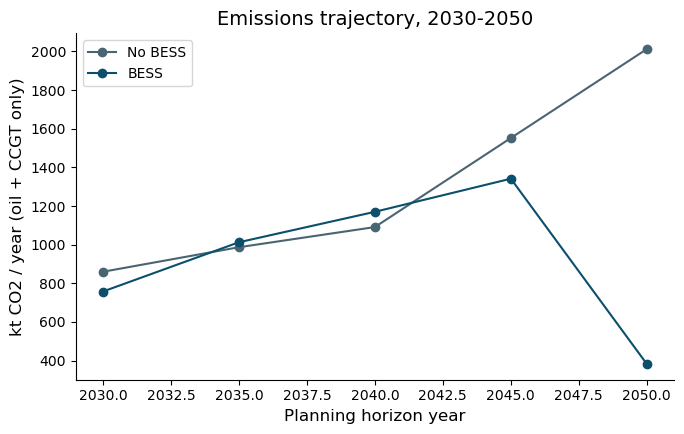

bess,bess,no_bess
year,,
2030,757.722700,859.972398
2035,1012.646959,986.944477
2040,1170.226423,1091.237528
2045,1341.649305,1552.110737
2050,382.610522,2012.480725


In [8]:
CO2_FACTORS = {"oil": 0.75, "CCGT": 0.40}  # tCO2/MWh, matching BESS_Cost_Structure_Analysis.ipynb

def emissions_kt(n):
    total = 0.0
    for carrier, factor in CO2_FACTORS.items():
        names = n.generators.index[n.generators.carrier == carrier]
        if len(names) == 0:
            continue
        total += n.generators_t.p[names].sum().sum() * factor / 1e3  # kt/year
    return total

em_rows = []
for year in YEARS:
    for bess in BESS_STATES:
        n = networks[(year, bess)]
        if n is None:
            continue
        em_rows.append({"year": year, "bess": bess, "kt_co2_per_year": emissions_kt(n)})
em_df = pd.DataFrame(em_rows)

fig, ax = plt.subplots(figsize=(7, 4.5))
for bess in BESS_STATES:
    d = em_df[em_df.bess == bess].sort_values("year")
    if len(d) == 0:
        continue
    ax.plot(d.year, d.kt_co2_per_year, marker="o", color=BESS_COLORS[bess], label=BESS_LABELS[bess])
ax.set_xlabel("Planning horizon year")
ax.set_ylabel("kt CO2 / year (oil + CCGT only)")
ax.set_title("Emissions trajectory, 2030-2050")
ax.legend()
savefig(fig, "trajectory_emissions")
plt.show()

em_df.pivot(index="year", columns="bess", values="kt_co2_per_year")
